This notebook is my attempt to re-create Adrian's proposed process for determining binary fractions via Joker samples.


# Bookkeeping

In [2]:
from astropy.io import fits  #Import libraries
from astropy.table import unique, Table
from astropy.io import ascii
from astropy.io.fits import writeto
from astropy.time import Time
import astropy.table as tab
import astropy.units as u
import astropy.constants as c

from glob import glob
from glob import iglob
import pathlib
import string
import os
import copy as cp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import scipy as sp

import thejoker as tj
import twobody as tb

In [3]:
def get_data(sID):
    """
    Given a star's APOGEE ID, collect its RV data into a Joker RV data object. Remove nan and RV_REJECT points
    """
    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked

    visit_mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    vreject_mask = (visits["STARFLAG"] &(2**19)==0) #Remove RV_REJECT things
    
    mask = visit_mask & vreject_mask
    
    col1 = visits["JD"][mask]
    col2 = visits["VHELIO"][mask]
    col3 = visits["VRELERR"][mask]
    
    col2.unit = u.km/u.s #Make sure the units are correct.
    col3.unit = u.km/u.s
    
    data = tj.RVData(t=col1, rv = col2, rv_err = col3) #Make into a Joker RV object
    
    return data

In [4]:
def get_full_data(sID):
    """
    Given a star's APOGEE ID, collect its RV data into a Joker RV data object. Do not remove RV_REJECT points
    """
    visits = all_visits[all_visits['APOGEE_ID']==sID] #Visits with failed/bad RVs will be masked

    visit_mask = np.invert(visits["VHELIO"].mask) #Invert the mask, then use it to remove masked entries.
    
    col1 = visits["JD"][visit_mask]
    col2 = visits["VHELIO"][visit_mask]
    col3 = visits["VRELERR"][visit_mask]
    
    col2.unit = u.km/u.s #Make sure the units are correct.
    col3.unit = u.km/u.s
    
    data = tj.RVData(t=col1, rv = col2, rv_err = col3) #Make into a Joker RV object
    
    return data

In [5]:
def mass2(p,k,e,mstar=1.0): #Calculate the mass of a binary companion
    """
    Calculate secondary mass for Keplerian orbit
    p - period (If units not given, assumed to be in days.)
    k - semi-amplitude (If units not given, assumed to be in km/s.)
    e - eccentricity 
    mstar - primary star mass (if units not given, assumed to be in solar masses. Default 1Msol)
    """
    
    if not('time' in u.get_physical_type(p)):
        p = p *u.day
    if not('speed' in u.get_physical_type(k)):
        k = k *(u.km/u.s)
    if not ('mass' in u.get_physical_type(mstar)):
        mstar = m *u.solMass

    k = np.abs(k)
    G = c.G
    mass_fn = (p * k**3)*(1-e**2)**(3/2) / (2*np.pi*G)

    M_one = (mass_fn*(mstar)**2)**(1./3.)
    M_two = (mass_fn*(mstar+M_one)**2)**(1./3.)
    m_sini = (mass_fn*(mstar+M_two)**2)**(1./3.)

    #print(msini)
    return m_sini.to(u.solMass)

In [6]:
def v_err_adj_2(v_err): #More sophisticated v_err adjustment
    if ('velocity' in u.get_physical_type(v_err)):
        v_err = (v_err.to(u.km/u.s)).value
    
    m = 1.13893 #Averages for multiple runs of RANSAC
    b = 0.424407

    v_err_adjusted = 10**(m*np.log10(v_err)+b)
    return v_err_adjusted *(u.km/u.s)

In [7]:
def get_m_gal(): #Will replace with a gaussian generator later. For now, our mass range is pretty tight, so this is a good approximation.
    return 0.7939423076923077 *u.solMass

In [8]:
def rand_sini(): #Generate a theta such that the random angles are distributed evenly over a sphere.
    r2 = np.random.rand()
    sini = np.sqrt(1 - r2**2)
    #sign = 2 * np.random.randint(2) - 1 #whether to take the positive or negative square root
    return sini #*sign

# Part 1: Generate Simulated star data

I've included this code in case you want to re-generate new simulated stars. However, as I'm including the already-generated stars and their corresponding Joker samples, I recommend skipping to the next section.


If you do run this section, you will need both a star-level APOGEE summary table, and a visit-level summary table. Put them in the directory, and adjust the paths below if needed

## Galaxy/field bookeeping

Here we extract the galaxy members, so that we can use their cadence/errors to generate fake stars similar to the real things.

In [9]:
all_star = Table.read('allStar-dr17-synspec_rev1.fits') #Star-level summary table
all_visits = Table.read('allVisit-dr17-synspec_rev1.fits') #Visit-level summary table

In [10]:
field = 'SEXTANS' #Field name
rv = 224.3       #Average radial velocity of the target (km/s)
pm_ra = -0.409   #Proper motion of the target
pm_dec = -0.047  ##mas/year

In [11]:
im_folder = "images/"+field #Make a place to output all images. I think I used a different folder for this notebook.

if not os.path.exists(im_folder):
    os.makedirs(im_folder)

In [12]:
rv_scatter = 7.9  #Spread of the target's radial velocity (default is to select stars within 3x this range)
pm_radius = 0.5   #Radius in the proper motion plane (uses simple distance from center)


In [13]:
apo_gal = all_star[all_star["FIELD"]==field] #Check number of stars in field
len(apo_gal)

265

In [14]:
rv_min = rv - (3*rv_scatter)  #Get ~3 standard deviations on either side of the galaxy's known rv scatter
rv_max = rv + (3*rv_scatter)

vcut_mask = (apo_gal["VHELIO_AVG"]>rv_min)&(apo_gal["VHELIO_AVG"]<rv_max)

In [15]:
pm_delta = np.sqrt( (apo_gal["GAIAEDR3_PMRA"]-pm_ra)**2 + (apo_gal["GAIAEDR3_PMDEC"]-pm_dec)**2)
pm_mask = pm_delta < pm_radius #Calculate 'distance' in proper motion space.
pm_mask = pm_mask.data

In [16]:
logg_mask = (apo_gal["LOGG"]<3)| (apo_gal["LOGG"]<3).mask 

In [17]:
apo_vpmg = apo_gal[vcut_mask & pm_mask & logg_mask]

In [18]:
apo_vpmg.sort("LOGG")
print(len(apo_vpmg)) 

66


## Fake star generation

We'll do this in two parts; First, generate stars with signal, second, generate stars without signal.

The actual write-functions are commented out so I wouldn't overwrite my existing data. Adjust as needed.

### With signal (binary system)

In [19]:
rng = np.random.default_rng(seed=42) #Again for reproducability 

In [20]:
kruns = 1 #Set the total number of fake RV curves here. Results in n*kruns stars, where n is number of stars in galaxy
n = 1

for star in apo_vpmg:
    sID = star["APOGEE_ID"]
    nom_visits = all_visits[all_visits["APOGEE_ID"]==sID] # Add something here about RV-reject?
    visit_mask = np.invert(nom_visits["VHELIO"].mask) #Remove masked (failed to fit) RVs.
    vreject_mask = (nom_visits["STARFLAG"] &(2**19)==0)  #Remove RVs flagged with rv_reject

    mask = visit_mask & vreject_mask
    
    visits = nom_visits[mask]

    out_path = "toy_data/fractest_"+field+"_sim_sig_rvrjt/"+sID +"/" #Sort toy data based on which original star they're generated from
    if not os.path.exists(out_path):
        os.makedirs(out_path)

    v_err = v_err_adj_2(visits["VRELERR"]) #Adjust error parameters

    toy_data = Table((visits["MJD"],v_err),names = ("MJD", "VRELERR"))  #Reuse errors and cadence of reals stars, generate fresh RVs
    toy_data.add_column(col = np.zeros(len(toy_data)),name="VHELIO")

    k=0 #Index to keep track of how many fake stars we've done for a given star. 

    while(k<kruns):
        P = 10**(rng.normal(5.03, 2.28)) * u.day #Generate a period according to Raghavan, then select according to desired range.
        if(P.value>1024 or P.value<12): 
            continue  #in the future, do actual calculation for surface period, based on log g of real star
        
        m1 = get_m_gal() #Assume primary mass of galaxy average (change to a distribution later) 
        m2 = (m1-(13*u.M_jupiter).to(u.solMass)) * np.random.rand() + (13*u.M_jupiter).to(u.solMass) #Random companion mass (brown dwarf)
        e = np.random.rand()                                                                         #minimum mass
        i = np.arcsin(rand_sini()) * u.radian  #Get random inclination
        omega = 360 *np.random.rand() * u.degree #longitude of ascending nodes
        M0 = 360 *np.random.rand() * u.degree  #Random phase

        elements = tb.TwoBodyKeplerElements(P=P, m1 = m1, m2 = m2, e = e, i = i, omega = omega, M0 = M0 )  
        orb1 = tb.KeplerOrbit(elements.get_body(1))   #Make an orbitial model based on our random params
        fake_rvs = orb1.radial_velocity(Time(visits["MJD"],format='mjd')) #Print out a set of RVs with real star's cadence

        mean_v = rng.normal(rv,rv_scatter)  #Generate a random average velocity for this star, according to galaxy average
        carmel = rng.normal(mean_v, visits["VRELERR"]) * (u.km/u.s)  #Generate some jitter about said average

        toy_data["VHELIO"]=fake_rvs + carmel  #Add our jitter to our signal

        orchid = fits.Header() #Make a header tracking our "true" orbital parameters
        orchid["P"] = (P.value, P.unit)
        orchid["m1"] = (m1.value, m1.unit)
        orchid["m2"] = (m2.value, m2.unit)
        orchid["e"] = e
        orchid["i"] = (i.value, i.unit)
        orchid["omega"] = (omega.value, omega.unit)
        orchid["phase"] = (M0.value, M0.unit)

        write_path = out_path + "rv_sim_"+str(k)+".fits" #Place to write our data

        hdu = fits.HDUList()
        hdu.append(fits.table_to_hdu(toy_data))  #Write data.
        hdu[0].header.extend(orchid)
        #hdu.writeto(write_path,overwrite = True)
        
        n+=1
        k+=1
  

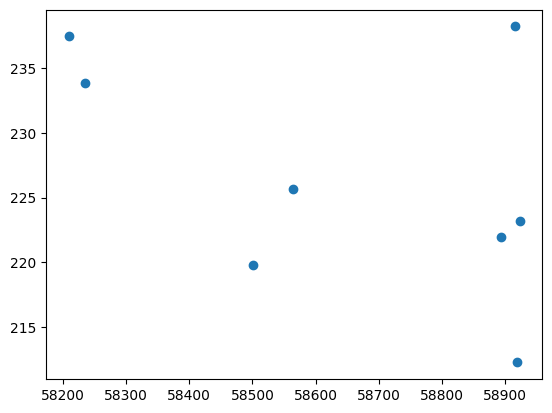

In [21]:
plt.scatter(toy_data["MJD"],toy_data["VHELIO"]) #Plot out the last generated star to make sure it looks okay.

### Without signal (single star w noise)

In [22]:
rng = np.random.default_rng(seed=42) #For reproducability

out_path = "toy_data/fractest_"+field+"_sim_xsig_rvrjt/" #Make a place to store simulated data.
if not os.path.exists(out_path):
    os.makedirs(out_path)

In [23]:
n = 1 #Index for file-tracking
for star in apo_vpmg: 
    sID = star["APOGEE_ID"]
    nom_visits = all_visits[all_visits["APOGEE_ID"]==sID] #Get the data from a real star, we'll use the same errors and cadence.
    
    visit_mask = np.invert(nom_visits["VHELIO"].mask) #Remove masked (failed to fit) RVs.
    vreject_mask = (nom_visits["STARFLAG"] &(2**19)==0)  #Remove RVs flagged with rv_reject

    mask = visit_mask & vreject_mask
    
    visits = nom_visits[mask]

    v_err = v_err_adj_2(visits["VRELERR"]) #Adjust errors according to our RANSAC simulations above

    toy_data = Table((visits["MJD"],v_err),names = ("MJD", "VRELERR")) #Use real star's errors and observation dates
    toy_data.add_column(col = np.zeros(len(toy_data)),name="VHELIO")   #Blank column for simulated data. 

    for i in range(1):
        mean_v = rng.normal(rv,rv_scatter) #Select a random RV based on galaxy's parameters 
        carmel = rng.normal(mean_v, visits["VRELERR"]) #Now generate random jitter about that star's 'mean' velocity

        toy_data["VHELIO"]=carmel 

        write_path = out_path + "sim_"+str(n)+".fits" #Output the resultant toy data
        #toy_data.write(write_path,overwrite=True)
        n+=1
    

# Part 2: Binary analysis

If you're running this notebook from scratch, take the simulated data above and run the Joker on it before running the next sections. 

If you already have the simulated data and Joker samples, start here

## Functions for calculating binary params

In [24]:
def get_K(M1, M2, P, e=0, i=90): #Calculate expected semi-amplitude from a mass
    """
    Calculate the expected semi-amplitude of a given binary system, given the masses.
    M1 - mass of primary body (If units not given, assumed to be in solar mass.)
    M2 - mass of secondary body (If units not given, assumed to be in solar mass.)
    P - orbital period (If units not given, assumed to be in days)
    i - inclination (assumed to be in degrees)
    e - ecentricity, should be between 0 and 1
    """

    if not('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.solMass
    if not('mass' in u.get_physical_type(M2)):
        M2 = M2 *u.solMass
    if not ('time' in u.get_physical_type(P)):
        P = P *u.day
    if not ('angle' in u.get_physical_type(i)):
        i = i * u.degree
        i = i.to(u.radian)
    
    qnt1 = (2*np.pi*c.G/P) / ((M2+M1)**2)
    K0 = qnt1**(1/3)* M2 * np.sin(i)
    K = K0 * (1-e**2)**(-1/2)
    return np.abs(K.to(u.km/u.s))

In [25]:
def get_K_randi(M1, M2, P, e=0): #A wraper for the above function to assign a random inclination
    i = rand_sini()*u.radian
    return get_K(M1, M2, P, e, i)

In [26]:
def get_mass2(P, K, e, M1=1.0, i=90): #Calculate companion mass from semi-amplitude
    """
    Calculate the expected companion mass of a system, given the semi-amplitude
    P - orbital period (If units not given, assumed to be in days)
    K - semi-amplitude of the primary body's RV (If units not given, assumed to be in km/s.)
    e - ecentricity, should be between 0 and 1
    M1 - mass of primary body (If units not given, assumed to be in solar mass.)
    i - inclination (assumed to be in degrees)
    """

    if not('time' in u.get_physical_type(P)):
        P = P *u.day
    if not('speed' in u.get_physical_type(K)):
        K = K *(u.km/u.s)
    if not ('angle' in u.get_physical_type(i)):
        i = i * u.degree
        i = i.to(u.radian)
    if not ('mass' in u.get_physical_type(M1)):
        M1 = M1 *u.solMass

    K = np.abs(K)  #Get the magnitude of K, sign doesn't matter but leads to weird math
    G = c.G
    mass_fn = (P * K**3)*(1-e**2)**(3/2) / (2*np.pi*G)  #Calculate the mass function of the system

    a = (M1/mass_fn) * np.sin(i)**3  #Calculate the (only non-trivial) polynomial coefficient (function expressed in q, the mass ratio)
    a = a.decompose() #make sure units are simplified.

    delta_0 = 1 + 6*a #Use the general cubic formula to find the real root of q (in depressed form)
    delta_1 = -2 -18*a - 27* a**2
    part1 = np.sqrt(delta_1 **2 - 4*(delta_0)**3)
    C1 = np.cbrt((delta_1 +part1)/ 2)

    q = (-1/(3*a)) *(-1 + C1 + delta_0/C1) #Convert out of depressed form

    return (q*M1.to(u.solMass)) #Convert mass ratio back to companion mass

In [27]:
def get_mass2_randi(p, k, e, M1=1.0): #A wraper for the above function to assign a random inclination
    i = rand_sini()*u.radian
    return get_mass2(p,k,e,M1, i)

Let's test the above functions on some bodies with known orbital parameters: Jupiter, and Beta Centauri Ab

In [28]:
get_mass2(11.862*u.year,0.0125,0.0489).to(u.jupiterMass) 

<Quantity 1.0020859 jupiterMass>

In [29]:
get_mass2( 356.9*u.day, 62.9*(u.km/u.s), 0.8245, i=67.68,  M1= 12.02)

<Quantity 10.10138637 solMass>

Pretty close, accurate to within sig-figs. Jupiter has mass $1 M_j$ (duh) and Beta Centauri Ab has mass $10.58\pm0.18M_\odot$


## Some bookkeeping we'll need later:

For the rest of this notebook, we are going to assume that $\sin(i) = 1$, and everything will be based on minimum mass estimates. This is an old galaxy, there could be some binaries with an unseen stellar remnant companion, so setting a maximum mass limit doesn't make much sense. 

In [30]:
min_p = 12*u.day 
max_p = 1400*u.day #twice our observing window

min_m2 = (13*u.jupiterMass).to(u.solMass)
max_m2 = 10*get_m_gal() #Not used, just here for posterity

max_K = get_K(get_m_gal(), max_m2, min_p, e=0) #Not used, just herefor posterity
min_K = get_K(get_m_gal(), min_m2, max_p, e=0) 

In [31]:
max_K

<Quantity 174.10050451 km / s>

In [32]:
min_K

<Quantity 0.27262286 km / s>

In [33]:
sig_path = "samples/SEXTANS/fractest_sim_samples_signal/" 
xsig_path = "samples/SEXTANS/fractest_sim_samples_xsignal/"
sig_sample_files = glob(sig_path+"*") 
xsig_sample_files = glob(xsig_path+"*") 

## Plot out the orbital parameters returned by the Joker

You can skip this section unless you want to re-make the various plots I have on my website.

First: Let's plot out the K and M valuesLet's mark out the "close binary" box on each star's plots.

- Minimum mass: 13 Jupiter masses (brown dwarf)
- Maximum mass: 0.79 Solar masses (assumed primary mass derived from an isochrone)
- Minimum period: 12 days (tidal circularization limit, using as proxy for stellar surface*)
- Maximum period: 1024 days (the maximum period we allowed in our fake star generator)

Note that the box/selection for K isn't working right, I think I might be inverting some min/max stuff. Process is ongoing.

*Since our targets are red giants, some of which have very low surface gravity, the minimum stable orbit around them will be larger in most cases. This is a lower limit for now.

In [34]:
out_path = "images/frac_test/"
if not os.path.exists(out_path):
    os.makedirs(out_path+"K")
    os.makedirs(out_path+"M2")  #It doesn't actually use this path right now, but you can configure the code below to make the plots without
    os.makedirs("images/frac_test/M2_randi/") #random inclination sampling.

(array([8., 4., 6., 2., 3., 2., 3., 4., 1., 3., 7., 6., 5., 4., 8.]),
 array([0.01431653, 0.06579293, 0.11726933, 0.16874573, 0.22022213,
        0.27169853, 0.32317492, 0.37465132, 0.42612772, 0.47760412,
        0.52908052, 0.58055692, 0.63203332, 0.68350972, 0.73498612,
        0.78646252]),
 <BarContainer object of 15 artists>)

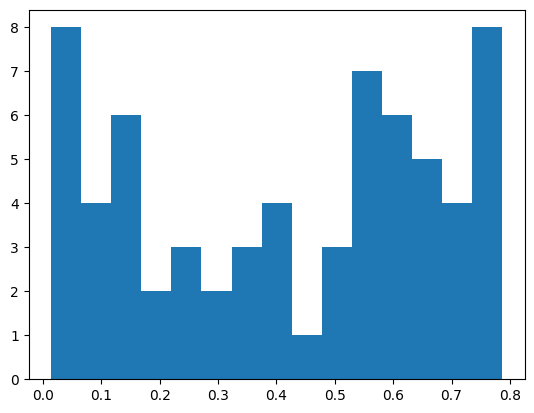

In [38]:
m2vals = np.empty(0)

for file in sig_sample_files:   #Stars with signal
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    source = fits.open("toy_data/fractest_SEXTANS_sim_sig_rvrjt/"+sID+"/rv_sim_0.fits")
    head = source[0].header

    m2vals = np.append(m2vals,head["M2"])

plt.hist(m2vals,bins=15)

In [203]:
for file in sig_sample_files:   #Stars with signal
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    source = fits.open("toy_data/fractest_SEXTANS_sim_sig_rvrjt/"+sID+"/rv_sim_0.fits")
    head = source[0].header

    k_im_path = "images/frac_test/K/" + sID + "_Kvals.png"
    m_im_path = "images/frac_test/M2/" + sID + "_Mvals.png"  #Change this path to "M2" if you are removing random inclinations.

    plt.figure(figsize=(6,4))

    plt.scatter(samples["P"],np.abs(samples["K"]))
    plt.scatter(head["P"], get_K(head["M1"], head["M2"], head["P"], e=head["E"], i=head["I"]*u.rad),color="black", marker='x') #plot actual values
    plt.xscale('log')

    ax = plt.gca()
    rect1 = patches.Rectangle((min_p.value,min_K.value), (max_p -min_p).value, (max_K-min_K).value, 
                              color='None', fc = 'chartreuse',alpha=0.5)
    ax.add_patch(rect1)

    plt.title("Semi-amplitude vs period")
    plt.xlabel("Period (days)")
    plt.ylabel("K (km/s)")

    plt.savefig(k_im_path,dpi=150,bbox_inches='tight')
    plt.close()
    #####################
    plt.figure(figsize=(6,4))
    comp_masses = get_mass2(samples["P"],samples["K"],samples["e"],M1=get_m_gal()) #Change this line to "get_mass2" to bypass
                                                                                        #random inclination sampling
    plt.scatter(samples["P"],comp_masses)
    plt.scatter(head["P"], head["M2"],color="black", label="True mass", marker="x")  #plot actual values
    plt.hlines(np.median(comp_masses).value, min(samples["P"]).value,max(samples["P"]).value, 
               color='red', label="Samples median",linestyles='dashed')
    plt.hlines(np.mean(comp_masses).value, min(samples["P"]).value,max(samples["P"]).value, 
               color='green', label="Samples mean",linestyles='dashed')
    plt.xscale('log')
    plt.yscale('log')

    ax = plt.gca()
    rect1 = patches.Rectangle((min_p.value,min_m2.value), (max_p -min_p).value, (max_m2-min_m2).value, 
                              color='None', fc = 'chartreuse',alpha=0.5)  #Yes I used chartreuse. Yes it looks awful. Will change later.
    ax.add_patch(rect1)

    plt.title("Companion mass vs period")
    plt.xlabel("Period (days)")
    plt.ylabel("M2 (solar mass) (km/s)")
    plt.legend()

    plt.savefig(m_im_path,dpi=150,bbox_inches='tight')
    plt.close()

In [196]:
get_K(head["M1"], head["M2"], head["P"], head["I"], head["E"])

<Quantity 0.15091687 km / s>

In [197]:
head["M2"]

0.5390262654176888

In [200]:
head

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
P       =   146.92467193011584 / d                                              
M1      =   0.7939423076923077 / solMass                                        
M2      =   0.5390262654176888 / solMass                                        
E       =   0.5623760035361104                                                  
I       =   1.5374825603445117 / rad                                            
OMEGA   =   50.678648244066096 / deg                                            
PHASE   =   143.50347416902002 / deg                                            

In [204]:
for file in xsig_sample_files:  #Stars without signal
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    k_im_path = "images/frac_test/K/" + sID + "_Kvals.png"
    m_im_path = "images/frac_test/M2/" + sID + "_Mvals.png" #Change this path to "M2" if you are removing random inclinations.

    plt.figure(figsize=(6,4))

    plt.scatter(samples["P"],np.abs(samples["K"]))
    plt.xscale('log')

    ax = plt.gca()
    rect1 = patches.Rectangle((min_p.value,min_K.value), (max_p -min_p).value, (max_K-min_K).value, 
                              color='None', fc = 'chartreuse',alpha=0.5)
    ax.add_patch(rect1)

    plt.title("Semi-amplitude vs period")
    plt.xlabel("Period (days)")
    plt.ylabel("K (km/s)")

    plt.savefig(k_im_path,dpi=150,bbox_inches='tight')
    plt.close()
    #####################
    plt.figure(figsize=(6,4))
    comp_masses = get_mass2(samples["P"],samples["K"],samples["e"],M1=get_m_gal()) #Change this line to "get_mass2" to bypass
                                                                                        #random inclination sampling
    plt.scatter(samples["P"],comp_masses)
    plt.hlines(np.median(comp_masses).value, min(samples["P"]).value,max(samples["P"]).value, 
               color='red', label="Samples median",linestyles='dashed')
    plt.hlines(np.mean(comp_masses).value, min(samples["P"]).value,max(samples["P"]).value, 
               color='green', label="Samples mean",linestyles='dashed')
    plt.xscale('log')
    plt.yscale('log')

    ax = plt.gca()
    rect1 = patches.Rectangle((min_p.value,min_m2.value), (max_p -min_p).value, (max_m2-min_m2).value, 
                              color='None', fc = 'chartreuse',alpha=0.5)
    ax.add_patch(rect1)

    plt.title("Companion mass vs period")
    plt.xlabel("Period (days)")
    plt.ylabel("M2 (solar mass) (km/s)")
    plt.legend()

    plt.savefig(m_im_path,dpi=150,bbox_inches='tight')
    plt.close()

In [195]:
max_m2

<Quantity 7.93942308 solMass>

Let's also make some RV curves for our stars.

In [91]:
out_path = "images/frac_test/rv_curves/"
if not os.path.exists(out_path):
    os.makedirs(out_path)


for file in sig_sample_files:
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]
    im_path = out_path+sID +"_rv_curve.png"

    source = fits.open("toy_data/fractest_SEXTANS_sim_sig_rvrjt/"+sID+"/rv_sim_0.fits")
    h = source[0].header
    rv_data = source[1].data
    rv_data = tj.RVData(t=rv_data["MJD"], rv = rv_data["VHELIO"] * (u.km/u.s), rv_err = rv_data["VRELERR"]* (u.km/u.s))

    elements = tb.TwoBodyKeplerElements(P=h["P"]*u.d, m1 = h["M1"]*u.solMass, m2 = h["M2"]*u.solMass, 
                                    e = h["e"], i = h["I"]*u.rad, omega = h["OMEGA"]*u.deg, M0 = h["PHASE"]*u.deg )  
    orb1 = tb.KeplerOrbit(elements.get_body(1))   #Make an orbitial model based on our random params
    curve_t = np.linspace(np.min(rv_data.t.value),np.max(rv_data.t.value),250)
    orig_rvs = orb1.radial_velocity(Time(curve_t,format='mjd')) + np.mean(rv_data.rv) #Use the mean of the data to estimate offset
                                                                                            #from galactic mean. Will change soon.
    plt.figure(figsize=(6,4))

    _ = tj.plot_rv_curves(samples, data=rv_data)

    plt.scatter(rv_data.t.mjd, rv_data.rv, color='black');
    plt.errorbar(rv_data.t.mjd, rv_data.rv, yerr=rv_data.rv_err, fmt="o", color='black');

    plt.plot(curve_t, orig_rvs.value, color="green")

    plt.savefig(im_path,dpi=150)
    plt.close()

In [92]:
for file in xsig_sample_files:
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]
    im_path = out_path+sID +"_rv_curve.png"

    source = fits.open("toy_data/fractest_SEXTANS_sim_xsig_rvrjt/sim_"+sID+".fits")
    rv_data = source[1].data
    rv_data = tj.RVData(t=rv_data["MJD"], rv = rv_data["VHELIO"] * (u.km/u.s), rv_err = rv_data["VRELERR"]* (u.km/u.s))

    plt.figure(figsize=(6,4))

    _ = tj.plot_rv_curves(samples, data=rv_data)

    plt.scatter(rv_data.t.mjd, rv_data.rv, color='black');
    plt.errorbar(rv_data.t.mjd, rv_data.rv, yerr=rv_data.rv_err, fmt="o", color='black');

    plt.savefig(im_path,dpi=150)
    plt.close()

## Make HTML table of simulated star plots

Skip skip this section, is for my own visualization purposes.

In [36]:
def mk_comp_row(file):
    with open("web_templates/bin_frac_row.txt","r") as f:
        row_tmp = f.read()

    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    params = (sID,
              sID, sID, sID,
              sID, sID, sID,
              sID, sID, sID,
              sID, sID, sID,)
    
    row_str = row_tmp % params
    return row_str

In [37]:
table_str = np.empty(0,dtype='U1000')

for file in sig_sample_files:
    row_str = mk_comp_row(file)
    table_str = np.append(table_str,row_str)

table_str = np.append(table_str,['\n\n'])

with open('bin_test_table.txt', 'w') as out:
    out.writelines(table_str)

In [38]:
table_str = np.empty(0,dtype='U1000')

for file in xsig_sample_files:
    row_str = mk_comp_row(file)
    table_str = np.append(table_str,row_str)

table_str = np.append(table_str,['\n\n'])

with open('bin_test_table_2.txt', 'w') as out:
    out.writelines(table_str)

# Binary fraction estimation

Now we get to the good stuff, me re-creating Adrian's method for estimating binary fractions. 

First, let's calculate the pass fractions (p-values) for each star: The fraction of Joker samples that fit our definition of "close stellar binary".

In [166]:
pass_fracs = np.empty(0)

for file in sig_sample_files:  #First for stars with signal
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    masses = get_mass2_randi(samples["P"], samples["K"], samples["e"], M1=get_m_gal())
    #print(np.mean(np.abs(samples["K"])))

    close_samples = (samples["P"]>min_p)& (samples["P"]<max_p)& (np.abs(samples["K"])>min_K)  #& (masses<max_m2)& (masses>min_m2)
    frac = np.sum(close_samples)/len(samples)

    pass_fracs = np.append(pass_fracs, frac)


In [167]:
pass_fracs

array([0.4765625 , 0.26953125, 0.5625    , 1.        , 0.96875   ,
       1.        , 0.2265625 , 0.19921875, 0.98828125, 1.        ,
       0.171875  , 0.30859375, 0.1640625 , 1.        , 1.        ,
       1.        , 1.        , 0.9921875 , 1.        , 1.        ,
       1.        , 0.2109375 , 0.4765625 , 0.171875  , 0.86328125,
       0.98828125, 0.3671875 , 0.91796875, 0.8984375 , 1.        ,
       1.        , 1.        , 0.22265625, 0.81640625, 1.        ,
       0.1484375 , 1.        , 0.6875    , 1.        , 1.        ,
       0.2421875 , 0.67578125, 1.        , 1.        , 1.        ,
       0.44921875, 0.171875  , 1.        , 1.        , 1.        ,
       0.3359375 , 0.52734375, 1.        , 1.        , 1.        ,
       0.25390625, 1.        , 1.        , 0.17578125, 1.        ,
       0.9921875 , 0.65234375, 1.        , 0.90234375, 1.        ,
       1.        ])

In [168]:
for file in xsig_sample_files:  #Then for the stars without signal
    samples = tj.JokerSamples.read(file)
    sID = pathlib.Path(file).parts[-1].split("_")[1]

    masses = get_mass2_randi(samples["P"], samples["K"], samples["e"], M1=get_m_gal())

    close_samples = (samples["P"]>min_p)&(samples["P"]<max_p)& (np.abs(samples["K"])>min_K)  #& (masses<max_m2)& (masses>min_m2)
    frac = np.sum(close_samples)/len(samples)

    pass_fracs = np.append(pass_fracs, frac)

    #print(frac)
    #print(len(samples))
    #print(sID)
    #print("")

In [169]:
pass_fracs

array([0.4765625 , 0.26953125, 0.5625    , 1.        , 0.96875   ,
       1.        , 0.2265625 , 0.19921875, 0.98828125, 1.        ,
       0.171875  , 0.30859375, 0.1640625 , 1.        , 1.        ,
       1.        , 1.        , 0.9921875 , 1.        , 1.        ,
       1.        , 0.2109375 , 0.4765625 , 0.171875  , 0.86328125,
       0.98828125, 0.3671875 , 0.91796875, 0.8984375 , 1.        ,
       1.        , 1.        , 0.22265625, 0.81640625, 1.        ,
       0.1484375 , 1.        , 0.6875    , 1.        , 1.        ,
       0.2421875 , 0.67578125, 1.        , 1.        , 1.        ,
       0.44921875, 0.171875  , 1.        , 1.        , 1.        ,
       0.3359375 , 0.52734375, 1.        , 1.        , 1.        ,
       0.25390625, 1.        , 1.        , 0.17578125, 1.        ,
       0.9921875 , 0.65234375, 1.        , 0.90234375, 1.        ,
       1.        , 0.1015625 , 0.23828125, 0.1015625 , 0.17578125,
       0.1328125 , 0.265625  , 0.6640625 , 0.23828125, 0.17968

In [170]:
print(np.mean(pass_fracs[0:65]))  #Doesn't have any physical meaning, was just curious.
print(np.mean(pass_fracs[65:-1]))

0.7457932692307693
0.20158617424242425


(array([17., 14.,  4.,  2.,  1.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.1484375 , 0.19101562, 0.23359375, 0.27617188, 0.31875   ,
        0.36132812, 0.40390625, 0.44648437, 0.4890625 , 0.53164063,
        0.57421875, 0.61679688, 0.659375  , 0.70195313, 0.74453125,
        0.78710938, 0.8296875 , 0.87226563, 0.91484375, 0.95742187,
        1.        ]),
 <BarContainer object of 20 artists>)

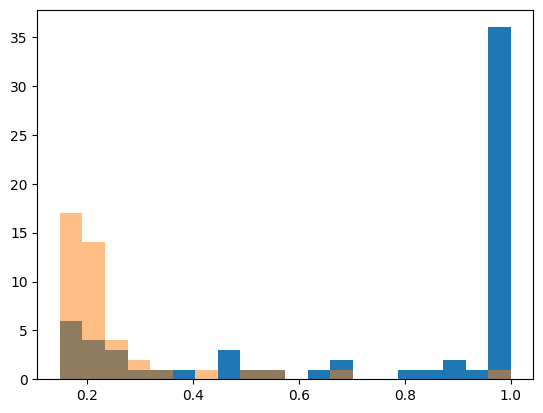

In [171]:
n, bins, foo = plt.hist(pass_fracs[0:65], bins = 20)
plt.hist(pass_fracs[65:-1], bins=bins, alpha=0.5)

## Binary fraction likelihood stuff.

Using the above p-values, let's try to estimate f (binary fraction) using (log) likelihoods.

In [172]:
def binary_fraction_log_likelihood(f, p_values):
    """Log-likelihood for binary fraction given per-star probabilities."""
    # avoid log(0)
    mix = np.clip((1 - f) * (1 - p_values) + f * p_values, 1e-12, 1.0)
    return np.sum(np.log(mix))

In [173]:
def neg_likelihood(f, p_values): #Wraper to invert the curve, because optimizers like minimizing, not maximizing.
    return -binary_fraction_log_likelihood(f, p_values)

In [174]:
def objective(f):  #Yet another wrapper to make function easier for the optimier to handle
    return neg_likelihood(f,pass_fracs)

In [175]:
binary_fraction_log_likelihood(0.25, pass_fracs) #Just to make sure it's running

-98.55925832584974

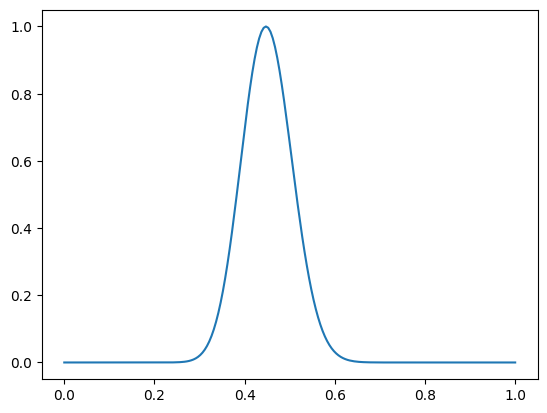

In [176]:
x = np.linspace(0,1,200)  #Let's see what the likelihood looks like as a function of f

ll = np.array([binary_fraction_log_likelihood(i, pass_fracs) for i in x])

plt.plot(x,np.exp(ll-np.max(ll)))

In [177]:
result = sp.optimize.minimize(objective, x0=0.5)

In [178]:
result.x

array([0.44729939])

This is fairly close to the expected value of 0.5

Do this with Joker samples instead: Grab random set of Joker samples.


In [224]:
def resample_joker_posteriors(file_list):
    pass_fracs = np.empty(0)
    
    for file in file_list:
        samples = tj.JokerSamples.read(file)
        
        if (len(samples)==1):
            inds=0
        else:
            inds = np.random.randint(0,len(samples)-1,len(samples))

        resampled = samples[inds]

        close_samples = (resampled["P"]>min_p)& (resampled["P"]<max_p)& (np.abs(resampled["K"])>min_K) 
        frac = np.sum(close_samples)/len(samples)

        pass_fracs = np.append(pass_fracs, frac)

    return pass_fracs

In [226]:
resampled_p = resample_joker_posteriors(sig_sample_files)
resampled_p = np.append(resampled_p, resample_joker_posteriors(xsig_sample_files))

array([0.4453125 , 0.328125  , 0.53515625, 1.        , 0.9609375 ,
       1.        , 0.21875   , 0.203125  , 0.98828125, 1.        ,
       0.171875  , 0.28515625, 0.15625   , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.22265625, 0.4609375 , 0.18359375, 0.859375  ,
       0.9921875 , 0.32421875, 0.9140625 , 0.921875  , 1.        ,
       1.        , 1.        , 0.23046875, 0.84765625, 1.        ,
       0.15625   , 1.        , 0.6484375 , 1.        , 1.        ,
       0.18359375, 0.7109375 , 1.        , 1.        , 1.        ,
       0.51953125, 0.1328125 , 1.        , 1.        , 1.        ,
       0.328125  , 0.5546875 , 1.        , 1.        , 1.        ,
       0.24609375, 1.        , 1.        , 0.15234375, 1.        ,
       0.9921875 , 0.62109375, 1.        , 0.91015625, 1.        ,
       1.        , 0.1015625 , 0.2734375 , 0.10546875, 0.15234375,
       0.171875  , 0.2734375 , 0.61328125, 0.234375  , 0.18359

In [239]:
resampled_f = np.empty(0)

for i in range(500):
    resampled_p = resample_joker_posteriors(sig_sample_files)
    resampled_p = np.append(resampled_p, resample_joker_posteriors(xsig_sample_files))

    def resamp_obj(f):  #Yet another wrapper to make function easier for the optimzier to handle
        return neg_likelihood(f,resampled_p)

    result = sp.optimize.minimize(resamp_obj, x0=0.5)

    resampled_f = np.append(resampled_f, result.x[0])

(array([ 2.,  4.,  8.,  8., 14., 23., 34., 59., 61., 57., 64., 40., 39.,
        38., 17., 13., 10.,  3.,  3.,  3.]),
 array([0.438877  , 0.43974993, 0.44062285, 0.44149578, 0.44236871,
        0.44324163, 0.44411456, 0.44498748, 0.44586041, 0.44673334,
        0.44760626, 0.44847919, 0.44935211, 0.45022504, 0.45109797,
        0.45197089, 0.45284382, 0.45371675, 0.45458967, 0.4554626 ,
        0.45633552]),
 <BarContainer object of 20 artists>)

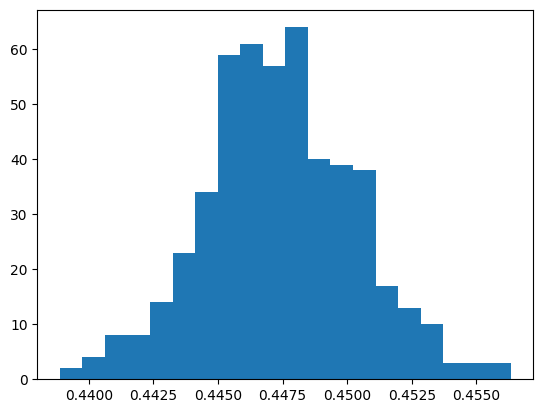

In [240]:
plt.hist(resampled_f, bins=20)

In [241]:
f_median = np.median(resampled_f)
f_16, f_84 = np.percentile(resampled_f, np.array([16, 84]))
print(
    f"Median bootstrap binary fraction: {f_median:.3f} (+{f_84 - f_median:.3f}/-{f_median - f_16:.3f})"
)

Median bootstrap binary fraction: 0.447 (+0.003/-0.002)


In [242]:
print(np.mean(resampled_f))
print(np.std(resampled_f))

0.4474120089652158
0.00292064939722456


### Old version 
(I resampled the stars instead of the individual star samples)

In [218]:
inds = np.random.randint(0,len(samples)-1,len(samples))
samples[inds]

<JokerSamples [P, e, omega, M0, s, K, v0, ln_likelihood, ln_prior] (256 samples)>

In [235]:
resampled_f = np.empty(0)

for i in range(5000):
    inds = np.random.randint(0,len(pass_fracs)-1,len(pass_fracs))
    resampled_fracs = pass_fracs[inds]

    def resamp_obj(f):  #Yet another wrapper to make function easier for the optimzier to handle
        return neg_likelihood(f,resampled_fracs)

    result = sp.optimize.minimize(resamp_obj, x0=0.5)

    resampled_f = np.append(resampled_f, result.x[0])

Text(0.5, 0, 'Binary fraction')

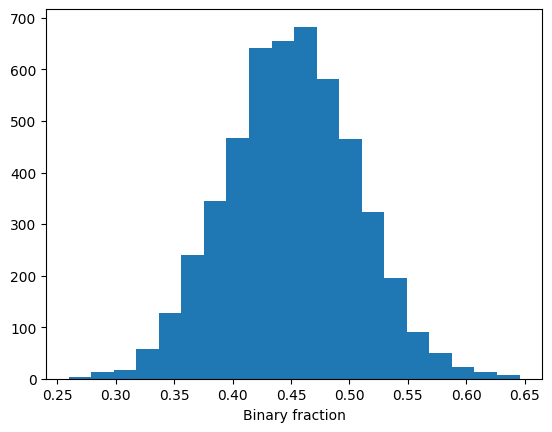

In [237]:
plt.hist(resampled_f, bins=20)
plt.xlabel("Binary fraction")

In [181]:
print(np.mean(resampled_f))
print(np.std(resampled_f))

0.4503256229951515
0.05641563681785884
